# 🧪 Laboratorio de Fundamentos · Módulo 1
### Redes Neuronales — Deep Learning · Maestría en Ciencia de Datos · Universidad Santo Tomás

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JotaMao1985/Deep_Learning_Usta/blob/main/notebooks/01-lab-fundamentos-modulo-1.ipynb)

Este cuaderno es el **complemento ejecutable** del material del Módulo 1: lleva de **una neurona en numpy** hasta **entrenar un perceptrón multicapa (MLP) en PyTorch**, reproduciendo en código las ideas de los Capítulos 1 a 5.

> **Cómo usarlo:** ejecutar las celdas en orden (en Google Colab: *Entorno de ejecución → Ejecutar todas*). Conviene cambiar los valores y volver a ejecutar para observar el efecto.

> ⚠️ **Importante:** este laboratorio usa **datos sintéticos** (no el café / RoCoLe) y **no constituye la solución de la Actividad 1 «El Guardián del Cafetal»**. Su propósito es practicar las herramientas que esa actividad evaluable exige.

---
**Contenido**
1. Una neurona desde cero · *Cap. 1–2*
2. Del error al aprendizaje: descenso del gradiente · *Cap. 3–4*
3. Un MLP de verdad en PyTorch · *Cap. 2*
4. Sobreajuste y cómo domarlo · *Cap. 5*
5. Puente a la Actividad 1

## 0. Preparación del entorno

Se importan las librerías (todas vienen preinstaladas en Colab) y se fija una **semilla** para que los resultados sean reproducibles.

In [1]:
# En Colab estas librerías ya están instaladas. Si faltara alguna, descomentar:
# !pip -q install torch scikit-learn matplotlib

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reproducibilidad: misma semilla -> mismos resultados
SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

# Paleta USTA para las gráficas
USTA_MORADO, USTA_ROSA, USTA_NAVY = "#3D008D", "#ED1E79", "#001A4D"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

print("Entorno listo · PyTorch", torch.__version__)

Entorno listo · PyTorch 2.12.0


## 1. Una neurona desde cero · *Cap. 1–2*

Una neurona artificial calcula una **suma ponderada** de sus entradas más un **sesgo**, y la pasa por una **función de activación** no lineal:

$$ z = \mathbf{w}^\top \mathbf{x} + b, \qquad a = \sigma(z) $$

- $\mathbf{x}$ son las entradas, $\mathbf{w}$ los pesos (importancia de cada entrada) y $b$ el sesgo (umbral base).
- $\sigma$ es la activación: **ReLU**, **Sigmoide** o **Tanh**. Sin ella, apilar capas equivaldría a una sola transformación lineal.

In [2]:
# Una neurona en numpy: z = w·x + b, seguida de una activación
x = np.array([0.8, 0.3, 0.6])    # entradas normalizadas (p. ej. altitud, humedad, sol)
w = np.array([0.9, -0.4, 0.7])   # pesos (importancia aprendida de cada entrada)
b = 0.1                          # sesgo (umbral base)

z = np.dot(w, x) + b             # suma ponderada
relu     = lambda v: np.maximum(0, v)
sigmoide = lambda v: 1 / (1 + np.exp(-v))
tanh     = lambda v: np.tanh(v)

print(f"z = w·x + b = {z:.3f}")
print(f"ReLU(z) = {relu(z):.3f}  |  Sigmoide(z) = {sigmoide(z):.3f}  |  Tanh(z) = {tanh(z):.3f}")

z = w·x + b = 1.120
ReLU(z) = 1.120  |  Sigmoide(z) = 0.754  |  Tanh(z) = 0.808


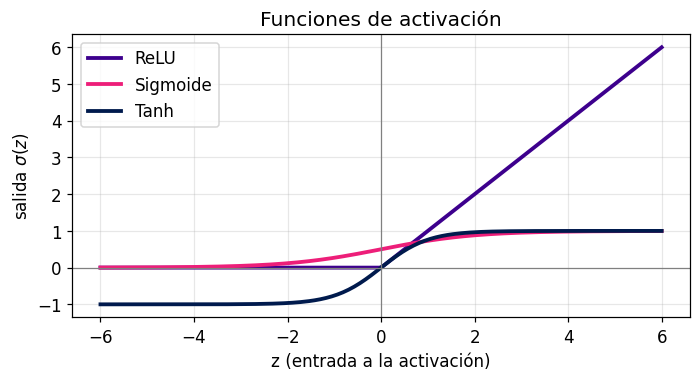

In [3]:
# Las tres activaciones, lado a lado
zz = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(zz, relu(zz),     color=USTA_MORADO, lw=2.5, label="ReLU")
ax.plot(zz, sigmoide(zz), color=USTA_ROSA,   lw=2.5, label="Sigmoide")
ax.plot(zz, tanh(zz),     color=USTA_NAVY,   lw=2.5, label="Tanh")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("z (entrada a la activación)"); ax.set_ylabel("salida $\\sigma(z)$")
ax.set_title("Funciones de activación"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Del error al aprendizaje · *Cap. 3–4*

Entrenar es **minimizar una función de pérdida** $L$ ajustando los parámetros en sentido **opuesto al gradiente**:

$$ \theta \leftarrow \theta - \eta \, \nabla_\theta L $$

donde $\eta$ es la **tasa de aprendizaje**. Una **época** es una pasada completa por los datos. La **retropropagación** (Cap. 4) es la regla de la cadena aplicada para calcular $\nabla_\theta L$ de forma eficiente.

A continuación se minimiza el «valle» $L(\theta)=\theta^2$ (con $\nabla L = 2\theta$) para tres tasas de aprendizaje.

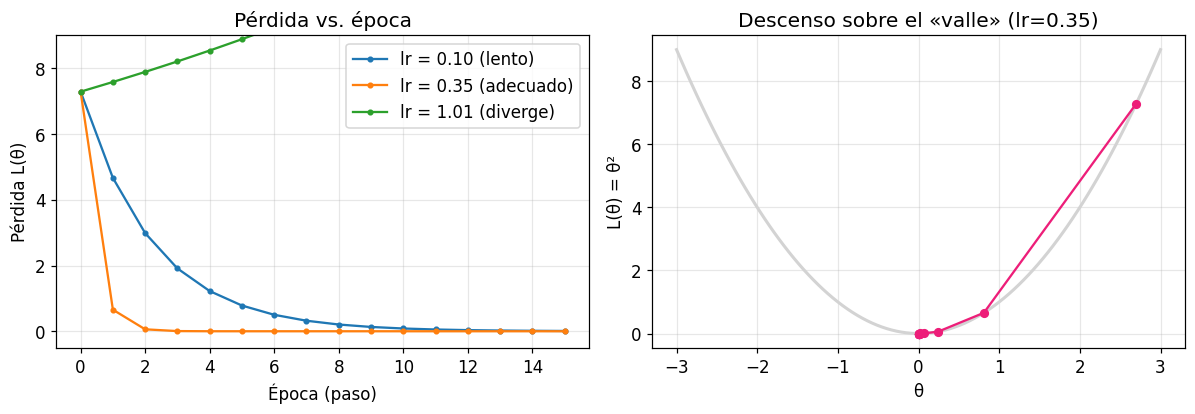

θ final con lr=0.35: 0.0000   (óptimo en θ = 0)


In [4]:
# Descenso del gradiente sobre L(theta) = theta^2
def descenso(theta0, lr, pasos=15):
    theta, hist = theta0, [theta0]
    for _ in range(pasos):
        grad = 2 * theta            # gradiente: pendiente en el punto actual
        theta = theta - lr * grad   # paso en sentido OPUESTO al gradiente
        hist.append(theta)
    return np.array(hist)

casos = {"lr = 0.10 (lento)": 0.10, "lr = 0.35 (adecuado)": 0.35, "lr = 1.01 (diverge)": 1.01}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
for nombre, lr in casos.items():
    h = descenso(2.7, lr)
    axes[0].plot(range(len(h)), h**2, marker="o", ms=3, label=nombre)
axes[0].set_ylim(-0.5, 9); axes[0].set_xlabel("Época (paso)"); axes[0].set_ylabel("Pérdida L(θ)")
axes[0].set_title("Pérdida vs. época"); axes[0].legend()

tt = np.linspace(-3, 3, 100); h = descenso(2.7, 0.35)
axes[1].plot(tt, tt**2, color="lightgray", lw=2)
axes[1].plot(h, h**2, marker="o", color=USTA_ROSA, ms=5)
axes[1].set_xlabel("θ"); axes[1].set_ylabel("L(θ) = θ²"); axes[1].set_title("Descenso sobre el «valle» (lr=0.35)")
plt.tight_layout(); plt.show()
print(f"θ final con lr=0.35: {descenso(2.7, 0.35)[-1]:.4f}   (óptimo en θ = 0)")

> **Lectura:** con $\eta$ pequeña el descenso es lento; con $\eta$ adecuada converge limpio; con $\eta$ demasiado grande **diverge** (la pérdida crece). Es el primer hiperparámetro a calibrar.

## 3. Un MLP de verdad en PyTorch · *Cap. 2*

Aquí se entrena un MLP de clasificación binaria sobre el conjunto **dos lunas** (`make_moons`), no separable por una recta. Se replican las piezas que pide la Actividad 1:

- una **clase** `nn.Module` con ≥ 2 capas ocultas (ReLU) y salida **Sigmoide**;
- pérdida **BCE** (entropía cruzada binaria) y optimizador **Adam**;
- un **bucle de entrenamiento explícito** con sus cinco pasos.

> 💡 *Para explorar:* cambiar `make_moons` por `make_circles` y volver a ejecutar desde aquí.

In [5]:
# Datos sintéticos: dos lunas entrelazadas (clasificación binaria no lineal)
X, y = make_moons(n_samples=300, noise=0.20, random_state=SEMILLA)
X = StandardScaler().fit_transform(X)                  # estandarizar ayuda a la convergencia
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, random_state=SEMILLA)

# A tensores de PyTorch (la pérdida BCE espera la salida con forma (N, 1))
def a_tensor(Xa, ya):
    return (torch.tensor(Xa, dtype=torch.float32),
            torch.tensor(ya, dtype=torch.float32).view(-1, 1))
X_tr_t, y_tr_t = a_tensor(X_tr, y_tr)
X_val_t, y_val_t = a_tensor(X_val, y_val)
print(f"Entrenamiento: {X_tr_t.shape[0]} puntos · Validación: {X_val_t.shape[0]} puntos")

Entrenamiento: 210 puntos · Validación: 90 puntos


In [6]:
class MLP(nn.Module):
    """MLP para clasificación binaria: 2 -> [oculta] * n_capas -> 1 (sigmoide)."""
    def __init__(self, n_entrada=2, n_oculta=16, n_capas=2, p_dropout=0.0):
        super().__init__()
        capas, d = [], n_entrada
        for _ in range(n_capas):
            capas += [nn.Linear(d, n_oculta), nn.ReLU()]   # capa oculta + no linealidad
            if p_dropout > 0:
                capas.append(nn.Dropout(p_dropout))        # regularización (se usa en la Sección 4)
            d = n_oculta
        capas += [nn.Linear(d, 1), nn.Sigmoid()]           # salida: probabilidad de la clase 1
        self.red = nn.Sequential(*capas)

    def forward(self, x):                                  # FORWARD PASS
        return self.red(x)

print(MLP(n_oculta=16, n_capas=2))

MLP(
  (red): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


### El bucle de entrenamiento, paso a paso
Cada época ejecuta cinco operaciones —las mismas que exige la Actividad 1—:
1. **`zero_grad`** — limpiar los gradientes de la época anterior.
2. **forward** — calcular las predicciones.
3. **error** — comparar con la verdad mediante la pérdida BCE.
4. **`backward`** — retropropagar el error (calcular los gradientes).
5. **`step`** — el optimizador actualiza los pesos.

In [7]:
def entrenar(modelo, Xt, yt, Xv, yv, epocas=200, lr=0.05, optimizador=torch.optim.Adam):
    criterio = nn.BCELoss()                       # entropía cruzada binaria
    opt = optimizador(modelo.parameters(), lr=lr)
    hist = {"train": [], "val": []}
    for epoca in range(epocas):
        modelo.train()
        opt.zero_grad()                 # 1. limpiar gradientes acumulados
        y_pred = modelo(Xt)             # 2. forward pass
        loss = criterio(y_pred, yt)     # 3. cálculo del error
        loss.backward()                 # 4. backward pass (retropropagación)
        opt.step()                      # 5. paso del optimizador (actualiza los pesos)
        # registro de la pérdida de validación
        modelo.eval()
        with torch.no_grad():
            val = criterio(modelo(Xv), yv)
        hist["train"].append(loss.item()); hist["val"].append(val.item())
    return hist

torch.manual_seed(SEMILLA)
modelo = MLP(n_oculta=16, n_capas=2)
hist = entrenar(modelo, X_tr_t, y_tr_t, X_val_t, y_val_t, epocas=200, lr=0.05)

modelo.eval()
with torch.no_grad():
    acc = ((modelo(X_val_t) >= 0.5).float() == y_val_t).float().mean().item()
print(f"Precisión en validación: {acc*100:.1f}%   ·   pérdida final: {hist['train'][-1]:.4f}")

Precisión en validación: 98.9%   ·   pérdida final: 0.0443


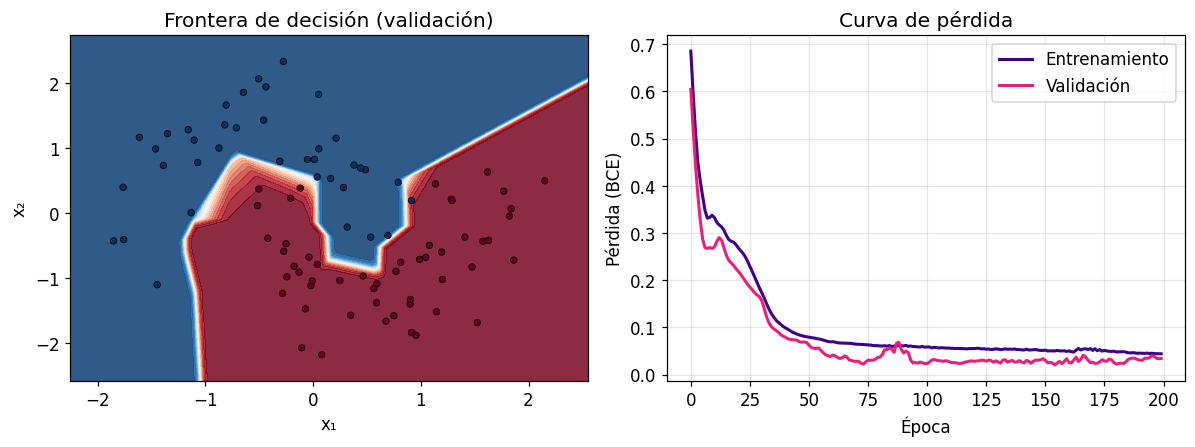

In [8]:
# Frontera de decisión (mapa de calor) + curva de pérdida
def frontera(modelo, Xa, ya, ax, titulo=""):
    x0, x1 = Xa[:, 0].min() - 0.4, Xa[:, 0].max() + 0.4
    y0, y1 = Xa[:, 1].min() - 0.4, Xa[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x0, x1, 200), np.linspace(y0, y1, 200))
    rejilla = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    modelo.eval()
    with torch.no_grad():
        Z = modelo(rejilla).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.85)
    ax.scatter(Xa[:, 0], Xa[:, 1], c=ya, cmap="RdBu_r", edgecolors="k", s=18, linewidths=0.5)
    ax.set_title(titulo); ax.set_xlabel("x₁"); ax.set_ylabel("x₂"); ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
frontera(modelo, X_val, y_val, axes[0], "Frontera de decisión (validación)")
axes[1].plot(hist["train"], color=USTA_MORADO, lw=2, label="Entrenamiento")
axes[1].plot(hist["val"],   color=USTA_ROSA,   lw=2, label="Validación")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Pérdida (BCE)")
axes[1].set_title("Curva de pérdida"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Sobreajuste y cómo domarlo · *Cap. 5*

Un modelo **sobreajusta** (*overfitting*) cuando memoriza el ruido del entrenamiento y **no generaliza**: la pérdida de entrenamiento baja, pero la de validación sube. Para provocarlo se usa una red **grande**, con **pocos datos ruidosos** y **muchas épocas**.

La cura es la **regularización**. Aquí se aplica **Dropout** (apagar neuronas al azar durante el entrenamiento); alternativas son `weight_decay` (L2) y *early stopping*.

In [9]:
# Receta para inducir sobreajuste: pocos datos + mucho ruido + red grande + muchas épocas
Xo, yo = make_moons(n_samples=160, noise=0.35, random_state=7)
Xo = StandardScaler().fit_transform(Xo)
Xo_tr, Xo_val, yo_tr, yo_val = train_test_split(Xo, yo, test_size=0.5, random_state=7)
Xo_tr_t, yo_tr_t = a_tensor(Xo_tr, yo_tr)
Xo_val_t, yo_val_t = a_tensor(Xo_val, yo_val)

torch.manual_seed(SEMILLA)
sin_reg = MLP(n_oculta=128, n_capas=3, p_dropout=0.0)
h_sin = entrenar(sin_reg, Xo_tr_t, yo_tr_t, Xo_val_t, yo_val_t, epocas=500, lr=0.01)

torch.manual_seed(SEMILLA)
con_reg = MLP(n_oculta=128, n_capas=3, p_dropout=0.30)   # Dropout del 30%
h_con = entrenar(con_reg, Xo_tr_t, yo_tr_t, Xo_val_t, yo_val_t, epocas=500, lr=0.01)

def precision(m, Xt, yt):
    m.eval()
    with torch.no_grad():
        return ((m(Xt) >= 0.5).float() == yt).float().mean().item()
print(f"SIN regularización → train {precision(sin_reg,Xo_tr_t,yo_tr_t)*100:.0f}%   val {precision(sin_reg,Xo_val_t,yo_val_t)*100:.0f}%")
print(f"CON Dropout 0.30   → train {precision(con_reg,Xo_tr_t,yo_tr_t)*100:.0f}%   val {precision(con_reg,Xo_val_t,yo_val_t)*100:.0f}%")

SIN regularización → train 100%   val 74%
CON Dropout 0.30   → train 99%   val 80%


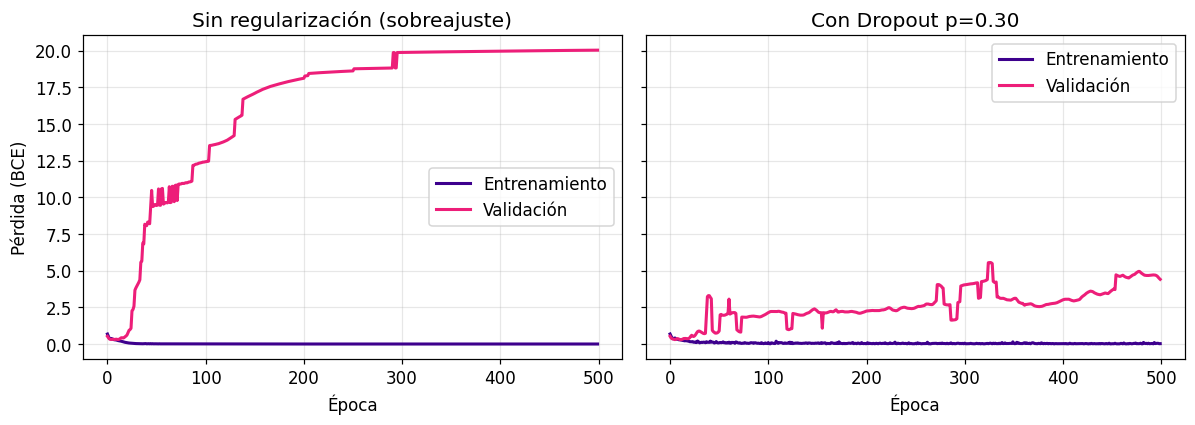

In [10]:
# Las curvas delatan el sobreajuste
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, h, t in [(axes[0], h_sin, "Sin regularización (sobreajuste)"),
                 (axes[1], h_con, "Con Dropout p=0.30")]:
    ax.plot(h["train"], color=USTA_MORADO, lw=2, label="Entrenamiento")
    ax.plot(h["val"],   color=USTA_ROSA,   lw=2, label="Validación")
    ax.set_xlabel("Época"); ax.set_title(t); ax.legend()
axes[0].set_ylabel("Pérdida (BCE)")
plt.tight_layout(); plt.show()

> **Las curvas lo delatan:** sin regularización, la pérdida de validación **se dispara** mientras la de entrenamiento cae a cero (memorización). Con **Dropout**, la brecha se reduce y la precisión en validación mejora. La **matriz de confusión** distingue además *falsos positivos* de *falsos negativos* — distinción central en la Guía de Profundización 1 (caso del dengue) y en la auditoría ética de la Actividad 1.

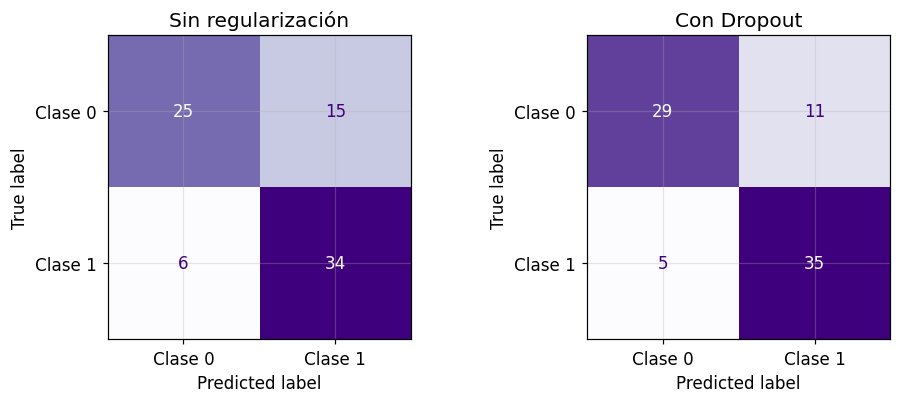

In [11]:
# Matriz de confusión sobre validación (antes vs. después de regularizar)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, m, t in [(axes[0], sin_reg, "Sin regularización"), (axes[1], con_reg, "Con Dropout")]:
    m.eval()
    with torch.no_grad():
        pred = (m(Xo_val_t) >= 0.5).int().numpy().ravel()
    cm = confusion_matrix(yo_val, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Clase 0", "Clase 1"]).plot(ax=ax, colorbar=False, cmap="Purples")
    ax.set_title(t)
plt.tight_layout(); plt.show()

## 5. Puente a la Actividad 1 «El Guardián del Cafetal»

Lo practicado aquí es **exactamente** el andamiaje técnico de la actividad evaluable — aplicado a datos sintéticos. La tabla traduce cada habilidad a su paso en el proyecto del café:

| En este laboratorio | En la Actividad 1 (café) |
|---|---|
| `make_moons` / `make_circles` | CSV pre-procesado de **RoCoLe** (hojas de café) |
| clase `MLP(nn.Module)` con 2 capas ocultas | misma estructura, justificando las activaciones |
| `BCELoss` + Adam | pérdida binaria + optimizador (SGD/Adam) |
| bucle explícito (zero_grad→forward→error→backward→step) | idéntico, por 50 épocas |
| curvas *train* vs. *val* | mismas curvas sobre los datos del café |
| Dropout para domar el sobreajuste | el **desafío** de inducir y corregir overfitting |
| matriz de confusión (FP vs. FN) | base de la **auditoría ética** (coste de los falsos positivos) |

> ⚠️ **Recordatorio:** este cuaderno **no** entrega la solución. El proyecto exige aplicar todo esto a los datos reales de café, añadir el informe técnico-ético y construir la rúbrica de evaluación.

> 📝 *Nota de escalado:* para conjuntos grandes conviene cargar los datos por lotes con `torch.utils.data.Dataset` y `DataLoader` (mini-batches), en lugar de pasar todo el tensor de una vez como aquí.

### 🔗 Relacionado
- Material interactivo del Módulo 1 (Capítulos 1–5) y el *laboratorio de fronteras de decisión* del Cap. 2.
- Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning*, Cap. 6 y 8. MIT Press.
- [TensorFlow Playground](https://playground.tensorflow.org) — intuición visual complementaria.